In [16]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

## 1. Custom Dataset Loader


In [17]:
class RetinopathyDataset(Dataset):
    def __init__(self, labels_file, image_dir, transform=None):
        # Support both Excel and CSV formats
        if labels_file.endswith('.csv'):
            self.labels_df = pd.read_csv(labels_file)
        else:
            self.labels_df = pd.read_excel(labels_file)
            
        self.image_dir = image_dir
        self.transform = transform
        
        # --- Filter DataFrame based on images that actually exist ---
        def check_image_exists(img_name):
            img_str = str(img_name)
            if not img_str.endswith('.jpeg'):
                img_str += '.jpeg'
            return os.path.exists(os.path.join(self.image_dir, img_str))
        
        # Apply the check to create a boolean mask
        original_len = len(self.labels_df)
        mask = self.labels_df['image'].apply(check_image_exists)
        
        # Filter the dataframe and reset the index
        self.labels_df = self.labels_df[mask].reset_index(drop=True)
        print(f"Dataset initialized: Found {len(self.labels_df)} matching images out of {original_len} total labels in the CSV.")

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = str(self.labels_df.iloc[idx]['image'])
        if not img_name.endswith('.jpeg'):
            img_name += '.jpeg'
            
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label = int(self.labels_df.iloc[idx]['level'])
        return image, label


## 2. Setup and Augmentation


In [18]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Paths - adjust these to match your environment
LABELS_PATH = 'trainLabels.csv' 
IMAGE_DIR = 'train_preprocessed' 

dataset = RetinopathyDataset(labels_file=LABELS_PATH, image_dir=IMAGE_DIR, transform=transform)

# Safety check: ensure we actually found some images before proceeding
if len(dataset) == 0:
    raise ValueError(f"No matching images found in '{IMAGE_DIR}'. Please check your paths and image extensions.")

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

Dataset initialized: Found 8408 matching images out of 35126 total labels in the CSV.


## 3. Model Definition (ResNet-50)


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pre-trained ResNet-50 and modify the final layer for 5 classes
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cpu


## 4. Training Loop


In [20]:
!pip install matplotlib

In [21]:
import matplotlib.pyplot as plt

num_epochs = 10

# Lists to store metrics for plotting
train_losses = []
train_accuracies = []

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    # Store metrics for this epoch
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

Starting Training...


KeyboardInterrupt: 

## 5. Visualize training process

Generating training plots...


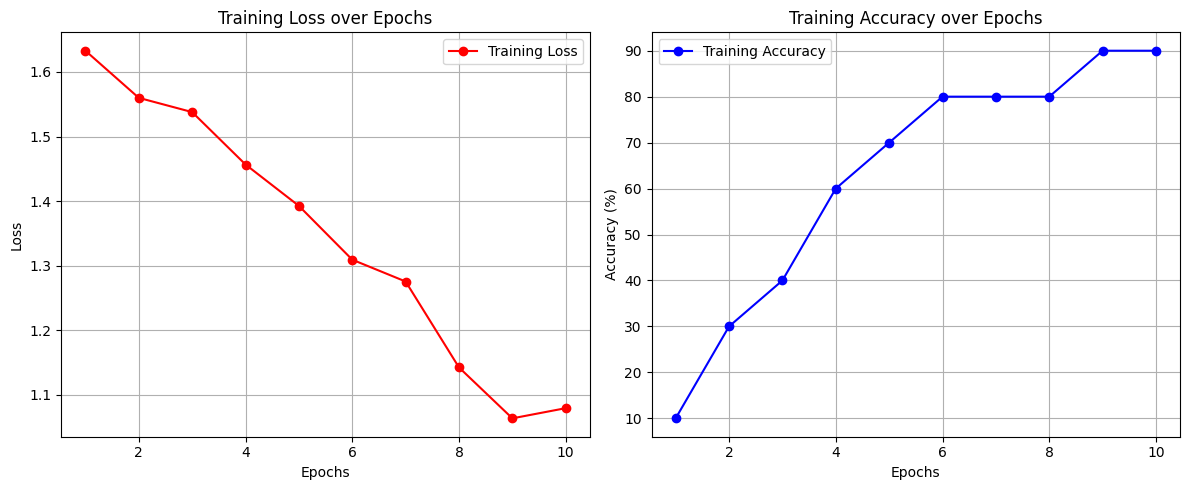

In [ ]:
print("Generating training plots...")

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
# Save the plot as an image file in your directory
plt.savefig('training_metrics_plot.png') 
# Display the plot
plt.show()